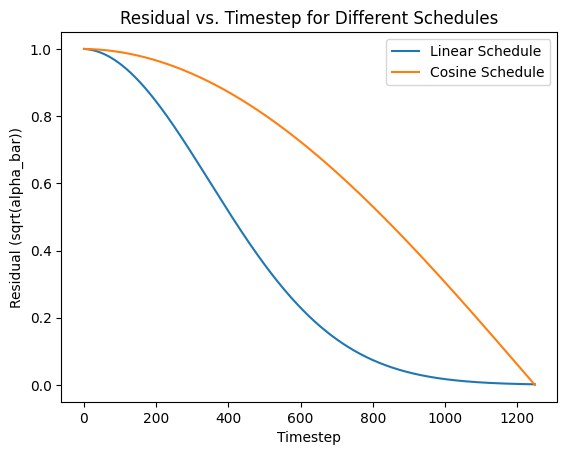

Final residual (Linear): 0.001794
Final residual (Cosine): 0.000000


In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Functions for beta schedules
def linear_beta_schedule(beta_start, beta_end, T):
    return np.linspace(beta_start, beta_end, T)

def cosine_beta_schedule(T, s=0.008):
    steps = T
    t = np.arange(steps + 1) / steps
    alphas_bar = np.cos(((t + s) / (1 + s)) * np.pi / 2) ** 2
    alphas_bar = alphas_bar / alphas_bar[0]
    alphas_bar = alphas_bar[1:]
    alphas_bar_prev = np.concatenate(([1.0], alphas_bar[:-1]))
    betas = 1 - alphas_bar / alphas_bar_prev
    return betas

# Compute residual sqrt(alpha_bar)
def compute_residual(betas):
    alphas = 1 - betas
    alpha_bars = np.cumprod(alphas)
    residual = np.sqrt(alpha_bars)
    return residual

# Simulation parameters
T = 1250
beta_start, beta_end = 1e-4, 2e-2

# Generate schedules and residuals
betas_linear = linear_beta_schedule(beta_start, beta_end, T)
res_linear = compute_residual(betas_linear)

betas_cosine = cosine_beta_schedule(T)
res_cosine = compute_residual(betas_cosine)

# Plot residuals over timesteps
plt.figure()
plt.plot(res_linear, label="Linear Schedule")
plt.plot(res_cosine, label="Cosine Schedule")
plt.xlabel("Timestep")
plt.ylabel("Residual (sqrt(alpha_bar))")
plt.title("Residual vs. Timestep for Different Schedules")
plt.legend()
plt.show()

# Print final residuals
print(f"Final residual (Linear): {res_linear[-1]:.6f}")
print(f"Final residual (Cosine): {res_cosine[-1]:.6f}")


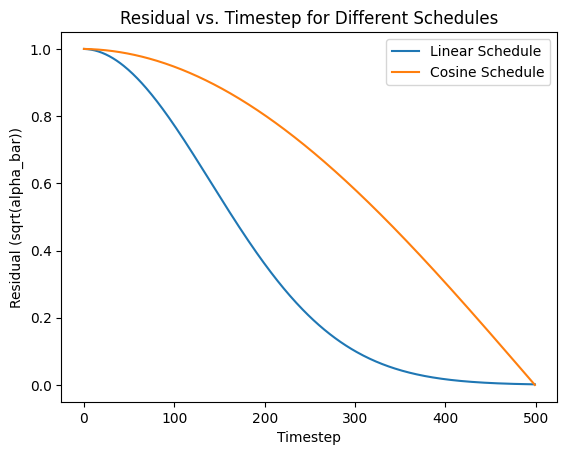

Final residual (Linear): 0.001713
Final residual (Cosine): 0.000000


In [2]:
import numpy as np
import matplotlib.pyplot as plt


# Functions for beta schedules
def linear_beta_schedule(beta_start, beta_end, T):
    return np.linspace(beta_start, beta_end, T)


def cosine_beta_schedule(T, s=0.008):
    steps = T
    t = np.arange(steps + 1) / steps
    alphas_bar = np.cos(((t + s) / (1 + s)) * np.pi / 2) ** 2
    alphas_bar = alphas_bar / alphas_bar[0]
    alphas_bar = alphas_bar[1:]
    alphas_bar_prev = np.concatenate(([1.0], alphas_bar[:-1]))
    betas = 1 - alphas_bar / alphas_bar_prev
    return betas


# Compute residual sqrt(alpha_bar)
def compute_residual(betas):
    alphas = 1 - betas
    alpha_bars = np.cumprod(alphas)
    residual = np.sqrt(alpha_bars)
    return residual


# Simulation parameters
T = 500
beta_start, beta_end = 1e-4, 5e-2

# Generate schedules and residuals
betas_linear = linear_beta_schedule(beta_start, beta_end, T)
res_linear = compute_residual(betas_linear)

betas_cosine = cosine_beta_schedule(T)
res_cosine = compute_residual(betas_cosine)

# Plot residuals over timesteps
plt.figure()
plt.plot(res_linear, label="Linear Schedule")
plt.plot(res_cosine, label="Cosine Schedule")
plt.xlabel("Timestep")
plt.ylabel("Residual (sqrt(alpha_bar))")
plt.title("Residual vs. Timestep for Different Schedules")
plt.legend()
plt.show()

# Print final residuals
print(f"Final residual (Linear): {res_linear[-1]:.6f}")
print(f"Final residual (Cosine): {res_cosine[-1]:.6f}")

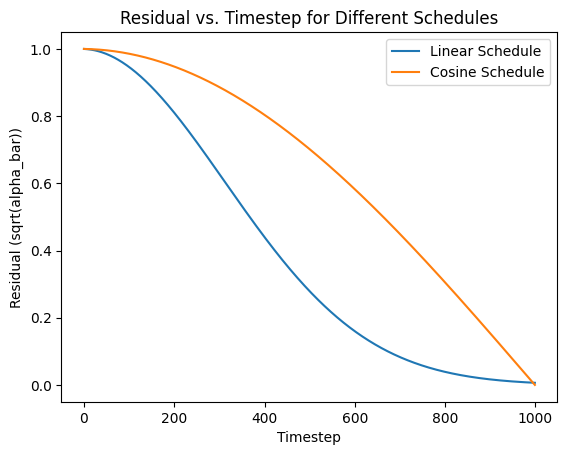

Final residual (Linear): 0.006353
Final residual (Cosine): 0.000000


In [3]:
import numpy as np
import matplotlib.pyplot as plt


# Functions for beta schedules
def linear_beta_schedule(beta_start, beta_end, T):
    return np.linspace(beta_start, beta_end, T)


def cosine_beta_schedule(T, s=0.008):
    steps = T
    t = np.arange(steps + 1) / steps
    alphas_bar = np.cos(((t + s) / (1 + s)) * np.pi / 2) ** 2
    alphas_bar = alphas_bar / alphas_bar[0]
    alphas_bar = alphas_bar[1:]
    alphas_bar_prev = np.concatenate(([1.0], alphas_bar[:-1]))
    betas = 1 - alphas_bar / alphas_bar_prev
    return betas


# Compute residual sqrt(alpha_bar)
def compute_residual(betas):
    alphas = 1 - betas
    alpha_bars = np.cumprod(alphas)
    residual = np.sqrt(alpha_bars)
    return residual


# Simulation parameters
T = 1000
beta_start, beta_end = 1e-4, 2e-2

# Generate schedules and residuals
betas_linear = linear_beta_schedule(beta_start, beta_end, T)
res_linear = compute_residual(betas_linear)

betas_cosine = cosine_beta_schedule(T)
res_cosine = compute_residual(betas_cosine)

# Plot residuals over timesteps
plt.figure()
plt.plot(res_linear, label="Linear Schedule")
plt.plot(res_cosine, label="Cosine Schedule")
plt.xlabel("Timestep")
plt.ylabel("Residual (sqrt(alpha_bar))")
plt.title("Residual vs. Timestep for Different Schedules")
plt.legend()
plt.show()

# Print final residuals
print(f"Final residual (Linear): {res_linear[-1]:.6f}")
print(f"Final residual (Cosine): {res_cosine[-1]:.6f}")

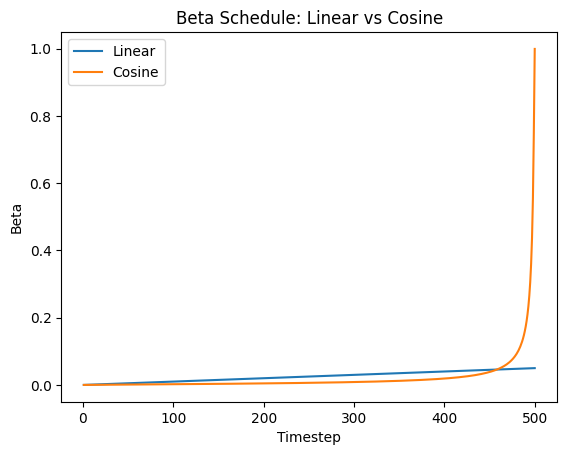

In [3]:
import numpy as np
import math
import matplotlib.pyplot as plt

# ―――――――――――――――――――――――――――――――――――
# パラメータ設定
T = 500
beta_start = 1e-4
beta_end = 5e-2
s = 0.008  # cosine シフト量
# ―――――――――――――――――――――――――――――――――――

# 線形スケジュール
betas_linear = np.linspace(beta_start, beta_end, T)

# improved DDPM の cosine スケジュール
steps = T + 1
t = np.linspace(0, T, steps)
alphas_cumprod = np.cos(((t / T + s) / (1 + s)) * math.pi / 2) ** 2
alphas_cumprod = alphas_cumprod / alphas_cumprod[0]
betas_cosine = 1.0 - alphas_cumprod[1:] / alphas_cumprod[:-1]
betas_cosine = np.clip(betas_cosine, None, 0.999)

# ―――――――――――――――――――――――――――――――――――
# プロット
plt.figure()
plt.plot(np.arange(1, T + 1), betas_linear)  # 線形
plt.plot(np.arange(1, T + 1), betas_cosine)  # 余弦
plt.xlabel("Timestep")
plt.ylabel("Beta")
plt.title("Beta Schedule: Linear vs Cosine")
plt.legend(["Linear", "Cosine"])
plt.show()

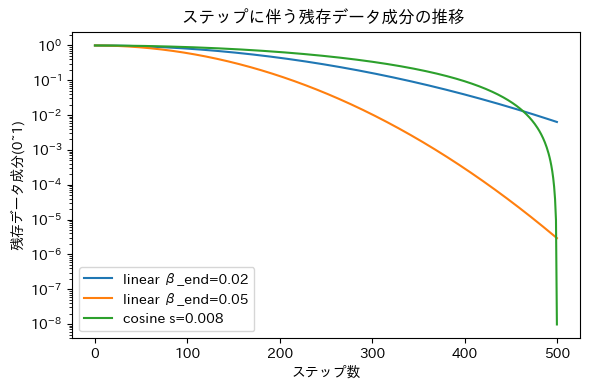

linear β_end=0.02 の最終残存率： 0.006352710797015061
linear β_end=0.05 の最終残存率： 2.933394115821278e-06
cosine s=0.008 の最終残存率： 9.715044036169864e-09


In [ ]:
import math
import numpy as np
import matplotlib.pyplot as plt
import japanize_matplotlib


def linear_alpha_bars(T, beta_start, beta_end):
    # リニアスケジュールでβ_tを生成し、α_t=1-β_t の累積積を返す
    betas = np.linspace(beta_start, beta_end, T)
    alphas = 1.0 - betas
    return np.cumprod(alphas)


def cosine_alpha_bars(T, s=0.008):
    # Cosineスケジュールのᾱ_tからβ_tを計算し、α_t=1-β_t の累積積を返す
    steps = T + 1
    t = np.linspace(0, T, steps)
    alphas_cumprod = np.cos(((t / T + s) / (1 + s)) * math.pi / 2) ** 2
    alphas_cumprod /= alphas_cumprod[0]
    betas = 1.0 - alphas_cumprod[1:] / alphas_cumprod[:-1]
    betas = np.clip(betas, None, 0.999)
    alphas = 1.0 - betas
    return np.cumprod(alphas)


# --- メイン ---
T = 500
ab1 = linear_alpha_bars(T, beta_start=1e-4, beta_end=2e-2)
ab2 = linear_alpha_bars(T, beta_start=1e-4, beta_end=5e-2)
ab3 = cosine_alpha_bars(T, s=0.008)

# ステップ0〜500
x = np.arange(0, T + 1)
y1 = np.concatenate(([1.0], ab1))
y2 = np.concatenate(([1.0], ab2))
y3 = np.concatenate(([1.0], ab3))

# プロット（対数スケール）
plt.figure(figsize=(6,4))
plt.semilogy(x, y1, label="linear β_end=0.02")
plt.semilogy(x, y2, label="linear β_end=0.05")
plt.semilogy(x, y3, label="cosine s=0.008")
plt.xlabel("ステップ数")
plt.ylabel("残存データ成分(0~1)")
plt.legend()
plt.title("ステップに伴う残存データ成分の推移 ")
plt.tight_layout()
plt.show()

# 最終ステップ(500)での残存値を表示
print("linear β_end=0.02 の最終残存率：", y1[-1])
print("linear β_end=0.05 の最終残存率：", y2[-1])
print("cosine s=0.008 の最終残存率：", y3[-1])

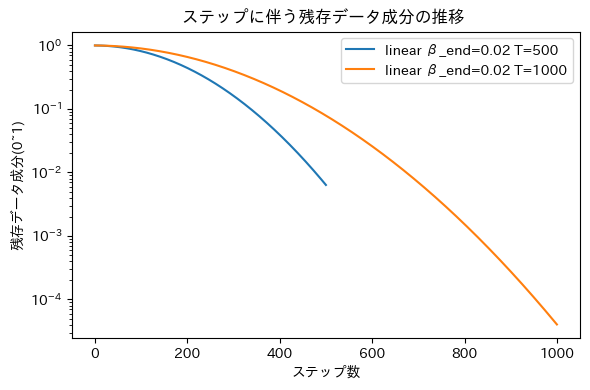

linear β_end=0.02 の最終残存率： 0.006352710797015061
linear β_end=0.05 の最終残存率： 4.035829765375676e-05


In [7]:
import math
import numpy as np
import matplotlib.pyplot as plt
import japanize_matplotlib


def linear_alpha_bars(T, beta_start, beta_end):
    # リニアスケジュールでβ_tを生成し、α_t=1-β_t の累積積を返す
    betas = np.linspace(beta_start, beta_end, T)
    alphas = 1.0 - betas
    return np.cumprod(alphas)


def cosine_alpha_bars(T, s=0.008):
    # Cosineスケジュールのᾱ_tからβ_tを計算し、α_t=1-β_t の累積積を返す
    steps = T + 1
    t = np.linspace(0, T, steps)
    alphas_cumprod = np.cos(((t / T + s) / (1 + s)) * math.pi / 2) ** 2
    alphas_cumprod /= alphas_cumprod[0]
    betas = 1.0 - alphas_cumprod[1:] / alphas_cumprod[:-1]
    betas = np.clip(betas, None, 0.999)
    alphas = 1.0 - betas
    return np.cumprod(alphas)


# --- メイン ---
T = 500
ab1 = linear_alpha_bars(T, beta_start=1e-4, beta_end=2e-2)
ab2 = linear_alpha_bars(1000, beta_start=1e-4, beta_end=2e-2)

# ステップ0〜500
x1 = np.arange(0, T + 1)
y1 = np.concatenate(([1.0], ab1))
x2 = np.arange(0, 1000 + 1)
y2 = np.concatenate(([1.0], ab2))

# プロット（対数スケール）
plt.figure(figsize=(6, 4))
plt.semilogy(x1, y1, label="linear β_end=0.02 T=500")
plt.semilogy(x2, y2, label="linear β_end=0.02 T=1000")
plt.xlabel("ステップ数")
plt.ylabel("残存データ成分(0~1)")
plt.legend()
plt.title("ステップに伴う残存データ成分の推移 ")
plt.tight_layout()
plt.show()

# 最終ステップ(500)での残存値を表示
print("linear β_end=0.02 の最終残存率：", y1[-1])
print("linear β_end=0.05 の最終残存率：", y2[-1])